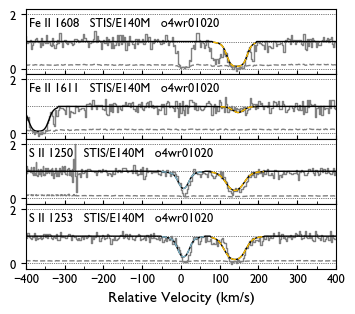

In [25]:
import os
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

def wave_to_vel(w, wrest, c_kms=299792.458):
    return c_kms * (w / wrest - 1.0)

def vel_to_wave(v, wrest, c_kms=299792.458):
    return wrest * (1.0 + v / c_kms)

def read_norm_spectrum(fitinsp_path, contfit_path):
    with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
        w1 = h1["WAVELENGTH"].data.astype(float)
        f1 = h1["FLUX"].data.astype(float)
        c1 = h1["CONTINUUM"].data.astype(float)
        e1 = h1["ERROR"].data.astype(float)

        w2 = h2["WAVELENGTH"].data.astype(float)
        f2 = h2["FLUX"].data.astype(float)
        c2 = h2["CONTINUUM"].data.astype(float)
        e2 = h2["ERROR"].data.astype(float)

    f1n = f1 / np.where(c1 == 0, np.nan, c1)
    e1n = e1 / np.where(c1 == 0, np.nan, c1)
    f2n = f2 / np.where(c2 == 0, np.nan, c2)
    e2n = e2 / np.where(c2 == 0, np.nan, c2)

    mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
    return w1[mask], f1n[mask], e1n[mask], f2n[mask], e2n[mask]

def style_axis(ax, xlim=(-400, 400), ylim=(0, 2), labelsize=10):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=labelsize)

# --- Desired line order (top -> bottom blocks) ---
LINE_COLS = [
    dict(label="Fe II 1142", wrest=1142.3660),
    dict(label="Fe II 1143", wrest=1143.2260),
    dict(label="Fe II 1608", wrest=1608.4511),
    dict(label="Fe II 1611", wrest=1611.2005),
    dict(label="Fe II 2249", wrest=2249.8768),
    dict(label="Fe II 2260", wrest=2260.7805),
    dict(label="S II 1250",  wrest=1250.5840),
    dict(label="S II 1253",  wrest=1253.8110),
]

c_kms = 299792.458
X_LIM = (-400, 400)
Y_LIM = (-0.2, 2.2)
COVERAGE_PAD_A = 0.5
WREST_MATCH_TOL_A = 1.0

# --- derive allowed lines per grating from your LINESETS ---
ALLOWED_LINES_BY_GRATING = {}
for grat, panel_list in LINESETS.items():
    allowed = []
    for p in panel_list:
        allowed.extend(p["lines"])
    ALLOWED_LINES_BY_GRATING[grat] = np.array(sorted(set(allowed)), dtype=float)

def grating_allows_line(grating, wrest, tol=1e-3):
    if grating not in ALLOWED_LINES_BY_GRATING:
        return False
    return np.any(np.abs(ALLOWED_LINES_BY_GRATING[grating] - wrest) < tol)

# --- collect all spectra (subdirs) across all spectra_directories ---
spectra_items = []
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory

    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if not path.exists():
        continue

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory=directory,
            subdir=subdir,
            subdir_path=subdir_path,
            contfit_path=cont_matches[0],
            fitinsp_path=fitinsp_matches[0],
            partial_paths=list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument=instrument,
            grating=grating,
        ))

# sort spectra within each line block (optional)
spectra_items.sort(key=lambda d: (d["grating"], d["subdir"]))

# --- build the vertical panel list: only include (line, spectrum) if it WILL plot ---
panels = []

for line in LINE_COLS:
    wrest = line["wrest"]

    for item in spectra_items:
        # must be allowed by LINESETS for that grating
        if not grating_allows_line(item["grating"], wrest, tol=1e-3):
            continue

        # must actually cover the wavelength window for this line
        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)
        w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
        w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A

        if (wmax < w_lo) or (wmin > w_hi):
            continue  # no coverage -> do not create this panel at all

        panels.append((line, item))

if len(panels) == 0:
    raise RuntimeError("No (line, spectrum) panels matched LINESETS + wavelength coverage.")


# --- build the vertical panel list: (line, spectrum) pairs that should exist ---
panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol=1e-3):
            continue
        panels.append((line, item))

if len(panels) == 0:
    raise RuntimeError("No (line, spectrum) panels matched LINESETS.")

# --- ONE figure, ALL vertical, share x-axis ---
fig, axes = plt.subplots(
    nrows=len(panels), ncols=1,
    figsize=(4, 0.75 * len(panels)),
    sharex=True
)

# --- x ticks on every panel: tick marks but NO numbers ---
major = MultipleLocator(100)   # major ticks every 100 km/s (change if you want)
minor = MultipleLocator(50)    # optional: minor ticks every 50 km/s

for ax in axes:
    ax.xaxis.set_major_locator(major)
    ax.xaxis.set_minor_locator(minor)  # comment out if you don't want minor ticks

    ax.tick_params(axis="x", which="major", bottom=True, top=False,
                   length=3, width=0.8, direction="in", labelbottom=False)
    ax.tick_params(axis="x", which="minor", bottom=True, top=False,
                   length=2, width=0.6, direction="in", labelbottom=False)

axes = np.atleast_1d(axes)

for ax, (line, item) in zip(axes, panels):
    wrest = line["wrest"]

    # read this spectrum (per panel; simple & robust)
    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    # optional: also require wavelength coverage for this line-window
    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle="steps-mid", lw=1.0, color="0.5")
    ax.plot(v, f1n, lw=1.0, color="0")
    ax.plot(v, e2n, lw=1.0, ls="--", color="0.5")

    # partial models for this spectrum routed to this line
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "#7FB3C8" if (z_partial is not None and z_partial < 0.0002) else "#FFC000"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        ax.plot(vp, mp_plot, lw=1, ls="--", color=colr)

    style_axis(ax, xlim=X_LIM, ylim=Y_LIM, labelsize=9)

    # horizontal reference lines at y=0,1,2
    for y in (0, 1, 2):
        ax.axhline(y, ls=":", lw=0.5, color="0", zorder=0)


    # left-side label: line + spectrum id
    ax.text(
        0.01, 0.78,
        f"{line['label']}   {item['instrument']}/{item['grating']}   {item['subdir']}",
        transform=ax.transAxes, ha="left", va="center", fontsize=9
    )

# x label only once at bottom
axes[-1].set_xlabel("Relative Velocity (km/s)", fontsize=11)

axes[-1].tick_params(axis="x", which="major", labelbottom=True)

fig.subplots_adjust(hspace=0.0, top=0.975)

outfile = target_directory / f"spectra_plots.png"

fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

In [2]:
import os
import re
import sys
import glob
import toml
import shutil
import textwrap
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from importlib import reload
from astropy.table import Table
from scipy.interpolate import interp1d
from joebvp import cfg, utils, VPmeasure

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Gill Sans"]

read_sets: Using set file -- 
  /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/lists/sets/llist_v1.3.ascii
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/morton03_table2.fits.gz
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/verner96_tab1.fits.gz
joebvp.makevoigt: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
joebvp.VPmeasure: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

In [3]:
target_directory = Path().resolve()
spectra_directories = sorted([d for d in os.listdir(target_directory) if d.startswith("G") or d.startswith("E")])
galaxy = target_directory.parts[target_directory.parts.index('float-for-morrow') + 1]
region = target_directory.parts[target_directory.parts.index("float-for-morrow") + 2]
target = target_directory.name
print(spectra_directories)
print(galaxy)
print(region)

['G130M_1291_LP4_1534.400_16101', 'G160M_1611_LP4_2336.032_16101']
SMC
SMC N88A


In [4]:
def parse_directory(dirname):

    Target = target_directory.name

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d) for d in spectra_directories]
df = pd.DataFrame.from_records(records)
display(df)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,2dFS 3694,COS,G130M,1291,LP4,None,1534.400,16101
1,2dFS 3694,COS,G160M,1611,LP4,None,2336.032,16101


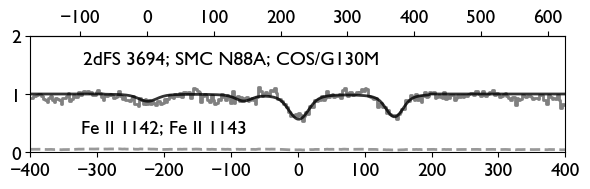

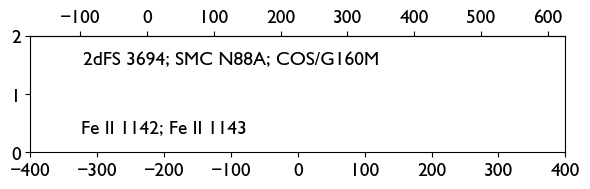

In [5]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        fe_1142 = 1142.3656
        fe_1143 = 1143.2260
        c_kms = 299792.458
        
        v_1142 = c_kms * (w / fe_1142 - 1.0)
        v_1143 = c_kms * (w / fe_1143 - 1.0)
        
        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return c_kms * (w_in / fe_1142 - 1.0)
        
        def v1142_to_v1143(v1142_in):
            w_in = fe_1142 * (1.0 + v1142_in / c_kms)
            return c_kms * (w_in / fe_1143 - 1.0)

        y0, y1 = 0.5, 1.5
        
        fig, ax = plt.subplots(figsize = (6, 2))

        ax.plot(v_1143, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        ax.plot(v_1143, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')
        ax.plot(v_1143, e2n, color =" 0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error")
        
        ax.text(-200, 0.4, "Fe II 1142; Fe II 1143", fontsize = 14, ha = "center", va = "center")
        ax.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)
        
        ax.tick_params(axis = "both", which = "major", labelsize = 14)
        ax.set_xlim(-400, 400)
        ax.set_ylim(0, 2)
        
        secax = ax.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis = "x", which = "major", labelsize = 14)
        
        fig.tight_layout()
        outfile = subdir_path / "Fe II 1142 1143.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

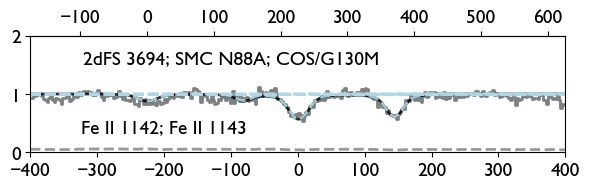

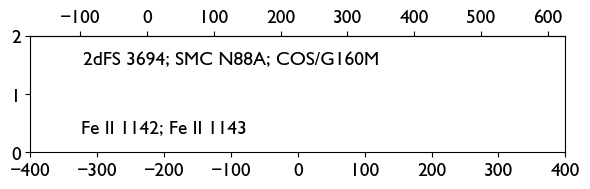

In [6]:
def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        partial_matches = list(subdir_path.glob("FitInspection_partial_*.fits"))  # <-- NEW

        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        fe_1142 = 1142.3656
        fe_1143 = 1143.2260
        c_kms = 299792.458

        v_1142 = c_kms * (w / fe_1142 - 1.0)
        v_1143 = c_kms * (w / fe_1143 - 1.0)

        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return c_kms * (w_in / fe_1142 - 1.0)

        def v1142_to_v1143(v1142_in):
            w_in = fe_1142 * (1.0 + v1142_in / c_kms)
            return c_kms * (w_in / fe_1143 - 1.0)

        fig, ax = plt.subplots(figsize=(6, 2))

        ax.plot(v_1143, f2n, drawstyle="steps-mid", lw=2.0,
                label="continuumfit: FLUX/CONTINUUM", color='0.5')
        ax.plot(v_1143, f1n, lw=2.0, alpha=0.8,
                label="FitInspection: FLUX/CONTINUUM", color='0')
        ax.plot(v_1143, e2n, color="0.5", ls="--", lw=2.0, alpha=0.8,
                label="continuumfit 1σ error")

        # ---------- NEW: read & overplot partial models ----------
        for ppath in partial_matches:
            z_partial, wrest_partial = parse_partial_meta(ppath.name)

            # If you only want the Fe II 1142/1143 partials, uncomment this filter:
            # if (wrest_partial is not None) and (abs(wrest_partial - fe_1142) > 2.0) and (abs(wrest_partial - fe_1143) > 2.0):
            #     continue

            try:
                with fits.open(ppath) as hp:
                    wp = hp["WAVELENGTH"].data.astype(float)
                    mp = hp["FLUX"].data.astype(float)  # model was written as "flux" in XSpectrum1D
            except Exception:
                continue

            goodp = np.isfinite(wp) & np.isfinite(mp)
            wp = wp[goodp]
            mp = mp[goodp]

            # put partial model on the same velocity axis you’re plotting (v_1143)
            vp_1143 = c_kms * (wp / fe_1143 - 1.0)

            # color rule by z
            if (z_partial is not None) and (z_partial < 0.0005):
                col = "lightblue"
            else:
                col = "yellow"

            ax.plot(vp_1143, mp, lw=2.0, ls="--", alpha=0.9, color=col)
        # --------------------------------------------------------

        ax.text(-200, 0.4, "Fe II 1142; Fe II 1143", fontsize=14, ha="center", va="center")
        ax.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}",
                ha="center", va="center", fontsize=14)

        ax.tick_params(axis="both", which="major", labelsize=14)
        ax.set_xlim(-400, 400)
        ax.set_ylim(0, 2)

        secax = ax.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis="x", which="major", labelsize=14)

        fig.tight_layout()
        outfile = subdir_path / "Fe II 1142 1143.png"
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

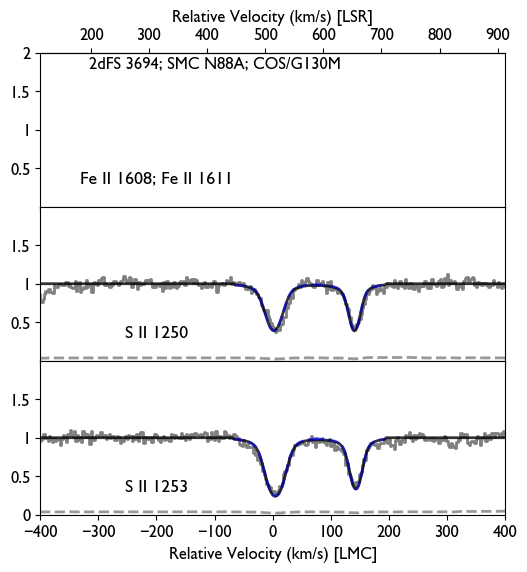

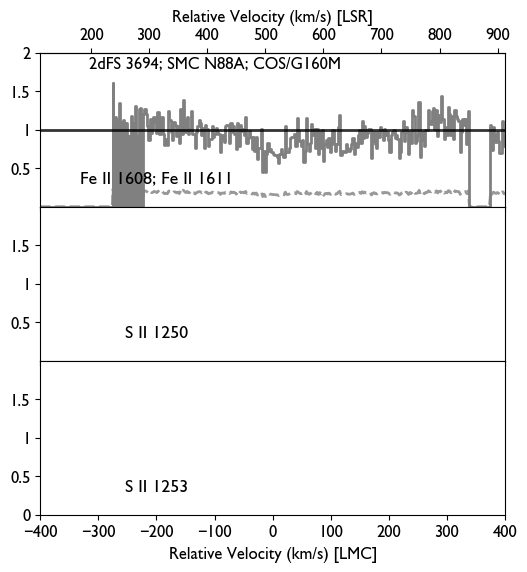

In [7]:
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

# helper: velocity axis (km/s) relative to rest wavelength
def wave_to_vel(w, wrest, c_kms=299792.458):
    return c_kms * (w / wrest - 1.0)

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        partial_matches = list(subdir_path.glob("FitInspection_partial_*.fits"))

        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        # normalize
        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        # rest wavelengths
        fe_1142 = 1608.451
        fe_1143 = 1611.201
        s_1250  = 1250.5840
        s_1253  = 1253.8110
        c_kms = 299792.458

        # velocity axes (each relative to its own rest wavelength)
        v_fe1143 = wave_to_vel(w, fe_1143, c_kms)
        v_s1250  = wave_to_vel(w, s_1250,  c_kms)
        v_s1253  = wave_to_vel(w, s_1253,  c_kms)

        # functions for secondary axis on Fe panel (Fe1143 <-> Fe1142)
        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return wave_to_vel(w_in, fe_1142, c_kms)

        def v1142_to_v1143(v_in):
            w_in = fe_1142 * (1.0 + v_in / c_kms)
            return wave_to_vel(w_in, fe_1143, c_kms)

        # ---- 3-panel figure with shared x ----
        fig, (ax_fe, ax_s1250, ax_s1253) = plt.subplots(
            nrows=3, ncols=1, figsize=(6, 6), sharex=True
        )

        # common styling helper
        def style_axis(ax):
            ax.set_xlim(-400, 400)
            ax.set_ylim(0, 2)
            ax.tick_params(axis="both", which="major", labelsize=12)

        # --- Panel 1: Fe II 1142/1143 (plotted on Fe1143 velocity axis) ---
        ax_fe.plot(v_fe1143, f2n, drawstyle="steps-mid", lw=2.0, color="0.5",
                   label="continuumfit: FLUX/CONTINUUM")
        ax_fe.plot(v_fe1143, f1n, lw=2.0, alpha=0.8, color="0",
                   label="FitInspection: FLUX/CONTINUUM")
        ax_fe.plot(v_fe1143, e2n, lw=2.0, ls="--", alpha=0.8, color="0.5",
                   label="continuumfit 1σ error")
        ax_fe.text(-200, 0.35, "Fe II 1608; Fe II 1611", fontsize=13,
                   ha="center", va="center")

        # secondary top x-axis ONLY for top panel
        secax = ax_fe.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis="x", which="major", labelsize=12)
        secax.set_xlabel("Relative Velocity (km/s) [LSR]", fontsize=12)

        style_axis(ax_fe)

        # --- Panel 2: S II 1250 ---
        ax_s1250.plot(v_s1250, f2n, drawstyle="steps-mid", lw=2.0, color="0.5")
        ax_s1250.plot(v_s1250, f1n, lw=2.0, alpha=0.8, color="0")
        ax_s1250.plot(v_s1250, e2n, lw=2.0, ls="--", alpha=0.8, color="0.5")
        ax_s1250.text(-200, 0.35, "S II 1250", fontsize=13,
                      ha="center", va="center")
        style_axis(ax_s1250)

        # --- Panel 3: S II 1253 ---
        ax_s1253.plot(v_s1253, f2n, drawstyle="steps-mid", lw=2.0, color="0.5")
        ax_s1253.plot(v_s1253, f1n, lw=2.0, alpha=0.8, color="0")
        ax_s1253.plot(v_s1253, e2n, lw=2.0, ls="--", alpha=0.8, color="0.5")
        ax_s1253.text(-200, 0.35, "S II 1253", fontsize=13,
                      ha="center", va="center")
        style_axis(ax_s1253)

        # one shared x label at the bottom
        ax_s1253.set_xlabel("Relative Velocity (km/s) [LMC]", fontsize=12)

        # instrument/title text (place above top panel)
        ax_fe.text(-100, 1.85, f"{target}; {region}; {instrument}/{grating}",
                   ha="center", va="center", fontsize=12)

        # -------- Overplot partial models on the appropriate panels --------
        for ppath in partial_matches:
            z_partial, wrest_partial = parse_partial_meta(ppath.name)

            if wrest_partial is None:
                continue

            # choose which panel based on wrest
            # (tolerances in Angstrom)
            if abs(wrest_partial - fe_1142) < 1.0 or abs(wrest_partial - fe_1143) < 1.0:
                axp = ax_fe
                wrest_for_vel = fe_1143  # match Fe panel x-axis definition
            elif abs(wrest_partial - s_1250) < 1.0:
                axp = ax_s1250
                wrest_for_vel = s_1250
            elif abs(wrest_partial - s_1253) < 1.0:
                axp = ax_s1253
                wrest_for_vel = s_1253
            else:
                continue

            try:
                with fits.open(ppath) as hp:
                    wp = hp["WAVELENGTH"].data.astype(float)
                    mp = hp["FLUX"].data.astype(float)  # model stored as FLUX
            except Exception:
                continue

            goodp = np.isfinite(wp) & np.isfinite(mp)
            wp = wp[goodp]
            mp = mp[goodp]

            vp = wave_to_vel(wp, wrest_for_vel, c_kms)

            col = "blue" if (z_partial is not None and z_partial < 0.0005) else "orange"

            mp_plot = mp.copy()
            mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
            
            axp.plot(vp, mp_plot, lw=2.0, ls="--", alpha=0.5, color=col)
        # -----------------------------------------------------------------

        # reduce clutter: no x tick labels on upper panels (sharex already helps)
        ax_fe.tick_params(labelbottom=False)
        ax_s1250.tick_params(labelbottom=False)

        ax_fe.set_yticks([0.5, 1, 1.5, 2])
        ax_fe.set_yticklabels(["0.5", "1", "1.5", "2"])
        ax_s1250.set_yticks([0.5, 1, 1.5])
        ax_s1250.set_yticklabels(["0.5", "1", "1.5"])
        ax_s1253.set_yticks([0, 0.5, 1, 1.5])
        ax_s1253.set_yticklabels(["0", "0.5", "1", "1.5"])


        fig.subplots_adjust(hspace=0)
        outfile = subdir_path / "FeII1142_1143_SII1250_SII1253.png"
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

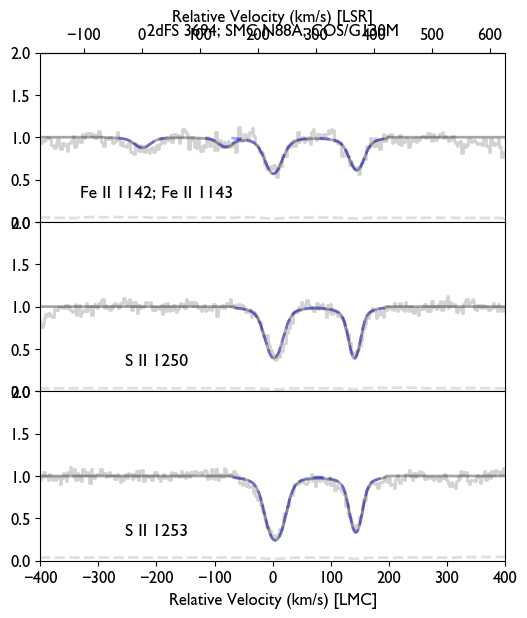

In [8]:
import os
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

def wave_to_vel(w, wrest, c_kms=299792.458):
    return c_kms * (w / wrest - 1.0)

def read_norm_spectrum(fitinsp_path, contfit_path):
    """Return wavelength and normalized flux/error arrays from your two FITS files."""
    with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
        w1 = h1["WAVELENGTH"].data.astype(float)
        f1 = h1["FLUX"].data.astype(float)
        c1 = h1["CONTINUUM"].data.astype(float)
        e1 = h1["ERROR"].data.astype(float)

        w2 = h2["WAVELENGTH"].data.astype(float)
        f2 = h2["FLUX"].data.astype(float)
        c2 = h2["CONTINUUM"].data.astype(float)
        e2 = h2["ERROR"].data.astype(float)

    f1n = f1 / np.where(c1 == 0, np.nan, c1)
    e1n = e1 / np.where(c1 == 0, np.nan, c1)
    f2n = f2 / np.where(c2 == 0, np.nan, c2)
    e2n = e2 / np.where(c2 == 0, np.nan, c2)

    mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
    return w1[mask], f1n[mask], e1n[mask], f2n[mask], e2n[mask]

def style_axis(ax, xlim=(-400, 400), ylim=(0, 2), labelsize=12):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=labelsize)

# ----------------- Define your per-grating “recipes” -----------------
# Each panel is one dict with:
#   - label: what to write on panel
#   - wrest_for_vel: rest wavelength used to define the velocity x-axis for that panel
#   - lines: list of rest wavelengths that should be considered "belonging" to this panel
#            (for partial models routing)
#
# For doublets, you can choose to plot them on a single velocity axis (like you did).
#
LINESETS = {
    "E230M": [
        dict(label="Fe II 2249; Fe II 2260",
             wrest_for_vel=2260.7805,  # choose one as x-axis definition
             lines=[2249.8768, 2260.7805]),
    ],
    "E140M": [
        dict(label="Fe II 1608; Fe II 1611",
             wrest_for_vel=1611.2005,
             lines=[1608.4511, 1611.2005]),
        dict(label="S II 1250",
             wrest_for_vel=1250.5840,
             lines=[1250.5840]),
        dict(label="S II 1253",
             wrest_for_vel=1253.8110,
             lines=[1253.8110]),
    ],
    "G130M": [
        dict(label="Fe II 1142; Fe II 1143",
             wrest_for_vel=1143.2260,  # pick one; adjust if you prefer the other
             lines=[1142.3660, 1143.2260]),
        dict(label="S II 1250",
             wrest_for_vel=1250.5840,
             lines=[1250.5840]),
        dict(label="S II 1253",
             wrest_for_vel=1253.8110,
             lines=[1253.8110]),
    ],
}

# If you want a top secondary axis for the first panel when it’s a doublet:
def add_secondary_axis_for_doublet(ax, wrest_primary, wrest_secondary, c_kms=299792.458):
    def vprim_to_vsec(v_in):
        w_in = wrest_primary * (1.0 + v_in / c_kms)
        return wave_to_vel(w_in, wrest_secondary, c_kms)
    def vsec_to_vprim(v_in):
        w_in = wrest_secondary * (1.0 + v_in / c_kms)
        return wave_to_vel(w_in, wrest_primary, c_kms)
    secax = ax.secondary_xaxis('top', functions=(vprim_to_vsec, vsec_to_vprim))
    secax.tick_params(axis="x", which="major", labelsize=12)
    secax.set_xlabel("Relative Velocity (km/s) [LSR]", fontsize=12)
    return secax

# ----------------- Main loop: one figure per directory, overplot all subdirs -----------------
c_kms = 299792.458

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory

    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    if grating not in LINESETS:
        # skip gratings you don’t care about
        continue

    panels = LINESETS[grating]
    nrows = len(panels)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=1, figsize=(6, 2.2 * nrows), sharex=True
    )
    if nrows == 1:
        axes = [axes]  # make it iterable

    # Title / header text once for the whole figure
    axes[0].text(
        0.5, 1.08, f"{target}; {region}; {instrument}/{grating}",
        transform=axes[0].transAxes, ha="center", va="bottom", fontsize=12
    )

    # Put panel labels and styling once
    for ax, p in zip(axes, panels):
        ax.text(-200, 0.35, p["label"], fontsize=13, ha="center", va="center")
        style_axis(ax)
    axes[-1].set_xlabel("Relative Velocity (km/s) [LMC]", fontsize=12)

    # Optional: add secondary axis only when first panel is a doublet (2 lines)
    # Uses wrest_for_vel as "primary"; uses the other line as secondary.
    first_panel = panels[0]
    if len(first_panel["lines"]) == 2:
        wrest_primary = first_panel["wrest_for_vel"]
        wrest_secondary = [w for w in first_panel["lines"] if w != wrest_primary][0]
        add_secondary_axis_for_doublet(axes[0], wrest_primary, wrest_secondary, c_kms=c_kms)

    # Now: loop through ALL spectra subdirs and overplot onto the SAME axes
    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        partial_matches = list(subdir_path.glob("FitInspection_partial_*.fits"))

        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        # Read and normalize once per subdir
        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(fitinsp_path, contfit_path)
        except Exception:
            continue

        # Plot this spectrum on each panel with that panel's velocity axis
        for ax, p in zip(axes, panels):
            v = wave_to_vel(w, p["wrest_for_vel"], c_kms)
            ax.plot(v, f2n, drawstyle="steps-mid", lw=2.0, color="0.5", alpha=0.35)
            ax.plot(v, f1n, lw=2.0, alpha=0.35, color="0")
            ax.plot(v, e2n, lw=2.0, ls="--", alpha=0.25, color="0.5")

        # Overplot partial models routed to the right panel
        for ppath in partial_matches:
            z_partial, wrest_partial = parse_partial_meta(ppath.name)
            if wrest_partial is None:
                continue

            # find panel whose "lines" list matches this partial wrest (tolerance in Å)
            axp = None
            panel_for_vel = None
            for ax, p in zip(axes, panels):
                if any(abs(wrest_partial - lw) < 1.0 for lw in p["lines"]):
                    axp = ax
                    panel_for_vel = p
                    break
            if axp is None:
                continue

            try:
                with fits.open(ppath) as hp:
                    wp = hp["WAVELENGTH"].data.astype(float)
                    mp = hp["FLUX"].data.astype(float)
            except Exception:
                continue

            goodp = np.isfinite(wp) & np.isfinite(mp)
            wp, mp = wp[goodp], mp[goodp]

            vp = wave_to_vel(wp, panel_for_vel["wrest_for_vel"], c_kms)

            col = "blue" if (z_partial is not None and z_partial < 0.0005) else "orange"
            mp_plot = mp.copy()
            mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
            axp.plot(vp, mp_plot, lw=2.0, ls="--", alpha=0.35, color=col)

    # Clean up tick labels on all but bottom
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

    fig.subplots_adjust(hspace=0)

    # Save ONE file per directory (i.e., combined over all spectra in that directory)
    outfile = path / f"{grating}_stacked_lines.png"
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

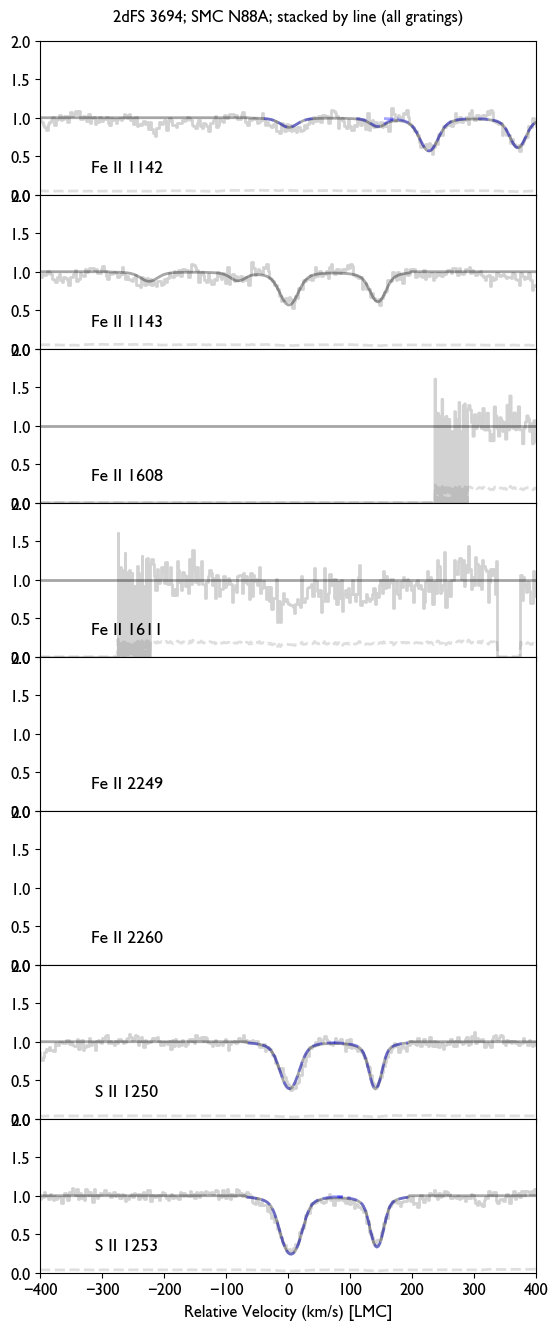

In [9]:
import os
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

def wave_to_vel(w, wrest, c_kms=299792.458):
    return c_kms * (w / wrest - 1.0)

def vel_to_wave(v, wrest, c_kms=299792.458):
    return wrest * (1.0 + v / c_kms)

def read_norm_spectrum(fitinsp_path, contfit_path):
    with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
        w1 = h1["WAVELENGTH"].data.astype(float)
        f1 = h1["FLUX"].data.astype(float)
        c1 = h1["CONTINUUM"].data.astype(float)
        e1 = h1["ERROR"].data.astype(float)

        w2 = h2["WAVELENGTH"].data.astype(float)
        f2 = h2["FLUX"].data.astype(float)
        c2 = h2["CONTINUUM"].data.astype(float)
        e2 = h2["ERROR"].data.astype(float)

    f1n = f1 / np.where(c1 == 0, np.nan, c1)
    e1n = e1 / np.where(c1 == 0, np.nan, c1)
    f2n = f2 / np.where(c2 == 0, np.nan, c2)
    e2n = e2 / np.where(c2 == 0, np.nan, c2)

    mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
    return w1[mask], f1n[mask], e1n[mask], f2n[mask], e2n[mask]

def style_axis(ax, xlim=(-400, 400), ylim=(0, 2), labelsize=12):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=labelsize)

# ----------------- Global desired ordering (one panel per line) -----------------
LINE_PANELS = [
    dict(label="Fe II 1142", wrest=1142.3660),
    dict(label="Fe II 1143", wrest=1143.2260),
    dict(label="Fe II 1608", wrest=1608.4511),
    dict(label="Fe II 1611", wrest=1611.2005),
    dict(label="Fe II 2249", wrest=2249.8768),
    dict(label="Fe II 2260", wrest=2260.7805),
    dict(label="S II 1250",  wrest=1250.5840),
    dict(label="S II 1253",  wrest=1253.8110),
]

# Matching partial-model wrest to a panel:
WREST_MATCH_TOL_A = 1.0

# Plot window and coverage logic:
COVERAGE_XLIM = (-400, 400)  # km/s
COVERAGE_PAD_A = 0.5         # Å (small pad to avoid edge misses)

c_kms = 299792.458

# ----------------- ONE FIGURE TOTAL (across all spectra_directories) -----------------
nrows = len(LINE_PANELS)
fig, axes = plt.subplots(
    nrows=nrows, ncols=1, figsize=(6.4, 2.0 * nrows), sharex=True
)
if nrows == 1:
    axes = [axes]

# Header text (edit to taste)
axes[0].text(
    0.5, 1.10, f"{target}; {region}; stacked by line (all gratings)",
    transform=axes[0].transAxes, ha="center", va="bottom", fontsize=12
)

# Panel labels + styling
for ax, p in zip(axes, LINE_PANELS):
    ax.text(-260, 0.35, p["label"], fontsize=13, ha="center", va="center")
    style_axis(ax, xlim=COVERAGE_XLIM)

axes[-1].set_xlabel("Relative Velocity (km/s) [LMC]", fontsize=12)

# Loop ALL directories (e.g., G130M/E140M/E230M dirs) and overplot everything
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory

    if not path.exists():
        continue

    # Loop spectra subdirs in this directory
    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        partial_matches = list(subdir_path.glob("FitInspection_partial_*.fits"))

        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        # Read and normalize once per subdir
        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(fitinsp_path, contfit_path)
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)

        # Plot this spectrum onto each line panel ONLY if it covers that line window
        for ax, p in zip(axes, LINE_PANELS):
            wrest = p["wrest"]
            w_lo = vel_to_wave(COVERAGE_XLIM[0], wrest, c_kms) - COVERAGE_PAD_A
            w_hi = vel_to_wave(COVERAGE_XLIM[1], wrest, c_kms) + COVERAGE_PAD_A

            # coverage test (fast)
            if (wmax < w_lo) or (wmin > w_hi):
                continue

            v = wave_to_vel(w, wrest, c_kms)
            ax.plot(v, f2n, drawstyle="steps-mid", lw=2.0, color="0.5", alpha=0.35)
            ax.plot(v, f1n, lw=2.0, alpha=0.35, color="0")
            ax.plot(v, e2n, lw=2.0, ls="--", alpha=0.25, color="0.5")

        # Overplot partial models routed to the right single-line panel
        for ppath in partial_matches:
            z_partial, wrest_partial = parse_partial_meta(ppath.name)
            if wrest_partial is None:
                continue

            # find matching panel
            axp = None
            wrest_for_vel = None
            for ax, p in zip(axes, LINE_PANELS):
                if abs(wrest_partial - p["wrest"]) < WREST_MATCH_TOL_A:
                    axp = ax
                    wrest_for_vel = p["wrest"]
                    break
            if axp is None:
                continue

            try:
                with fits.open(ppath) as hp:
                    wp = hp["WAVELENGTH"].data.astype(float)
                    mp = hp["FLUX"].data.astype(float)
            except Exception:
                continue

            goodp = np.isfinite(wp) & np.isfinite(mp)
            wp, mp = wp[goodp], mp[goodp]
            vp = wave_to_vel(wp, wrest_for_vel, c_kms)

            col = "blue" if (z_partial is not None and z_partial < 0.0005) else "orange"
            mp_plot = mp.copy()
            mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
            axp.plot(vp, mp_plot, lw=2.0, ls="--", alpha=0.35, color=col)

# Clean up tick labels on all but bottom
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

fig.subplots_adjust(hspace=0)

# Save ONE file total
outfile = target_directory / f"{target}_{region}_ALLLINES_stacked_by_line.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

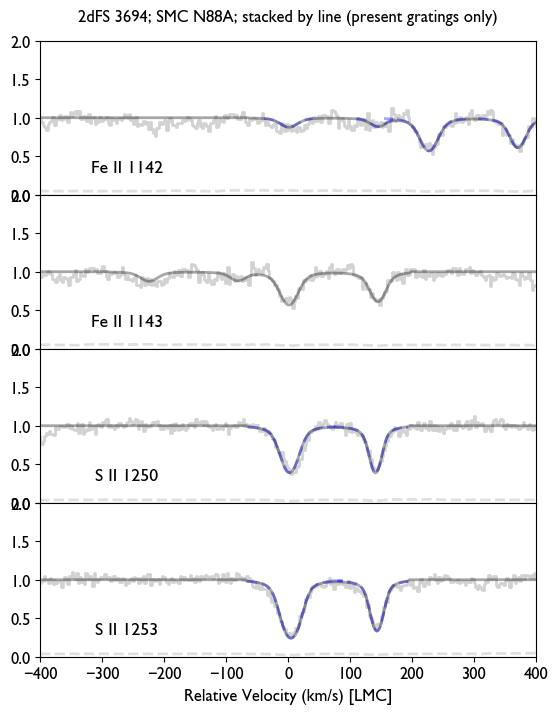

In [10]:
# ----------------- Decide which gratings are actually present (and exist on disk) -----------------
present_gratings = set()

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    if not path.exists():
        continue  # directory not on disk => ignore

    grating = df.loc[i, "Grating"]
    if grating in LINESETS:
        present_gratings.add(grating)

# union of allowed rest wavelengths for the gratings we actually have
allowed_wrests = set()
for grat in present_gratings:
    for panel in LINESETS[grat]:
        for lw in panel["lines"]:
            allowed_wrests.add(float(lw))

# filter the global panels list to only those lines supported by present gratings
LINE_PANELS_TO_PLOT = [p for p in LINE_PANELS if p["wrest"] in allowed_wrests]

if len(LINE_PANELS_TO_PLOT) == 0:
    raise RuntimeError("No supported gratings/lines found for this target (check paths and LINESETS).")

# ----------------- ONE FIGURE TOTAL (only for lines that exist for this target) -----------------
nrows = len(LINE_PANELS_TO_PLOT)
fig, axes = plt.subplots(
    nrows=nrows, ncols=1, figsize=(6.4, 2.0 * nrows), sharex=True
)
if nrows == 1:
    axes = [axes]

axes[0].text(
    0.5, 1.10, f"{target}; {region}; stacked by line (present gratings only)",
    transform=axes[0].transAxes, ha="center", va="bottom", fontsize=12
)

for ax, p in zip(axes, LINE_PANELS_TO_PLOT):
    ax.text(-260, 0.35, p["label"], fontsize=13, ha="center", va="center")
    style_axis(ax, xlim=COVERAGE_XLIM)

axes[-1].set_xlabel("Relative Velocity (km/s) [LMC]", fontsize=12)

# ----------------- Plot loop: use LINE_PANELS_TO_PLOT everywhere -----------------
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory

    if not path.exists():
        continue

    grating = df.loc[i, "Grating"]
    if grating not in LINESETS:
        continue  # ignore gratings you didn't define

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        partial_matches = list(subdir_path.glob("FitInspection_partial_*.fits"))

        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(fitinsp_path, contfit_path)
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)

        # plot only into panels that exist for this target
        for ax, p in zip(axes, LINE_PANELS_TO_PLOT):
            wrest = p["wrest"]
            w_lo = vel_to_wave(COVERAGE_XLIM[0], wrest, c_kms) - COVERAGE_PAD_A
            w_hi = vel_to_wave(COVERAGE_XLIM[1], wrest, c_kms) + COVERAGE_PAD_A
            if (wmax < w_lo) or (wmin > w_hi):
                continue

            v = wave_to_vel(w, wrest, c_kms)
            ax.plot(v, f2n, drawstyle="steps-mid", lw=2.0, color="0.5", alpha=0.35)
            ax.plot(v, f1n, lw=2.0, alpha=0.35, color="0")
            ax.plot(v, e2n, lw=2.0, ls="--", alpha=0.25, color="0.5")

        # partial models: route to existing panels only
        for ppath in partial_matches:
            z_partial, wrest_partial = parse_partial_meta(ppath.name)
            if wrest_partial is None:
                continue

            axp = None
            wrest_for_vel = None
            for ax, p in zip(axes, LINE_PANELS_TO_PLOT):
                if abs(wrest_partial - p["wrest"]) < WREST_MATCH_TOL_A:
                    axp = ax
                    wrest_for_vel = p["wrest"]
                    break
            if axp is None:
                continue

            try:
                with fits.open(ppath) as hp:
                    wp = hp["WAVELENGTH"].data.astype(float)
                    mp = hp["FLUX"].data.astype(float)
            except Exception:
                continue

            goodp = np.isfinite(wp) & np.isfinite(mp)
            wp, mp = wp[goodp], mp[goodp]
            vp = wave_to_vel(wp, wrest_for_vel, c_kms)

            col = "blue" if (z_partial is not None and z_partial < 0.0005) else "orange"
            mp_plot = mp.copy()
            mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
            axp.plot(vp, mp_plot, lw=2.0, ls="--", alpha=0.35, color=col)

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

fig.subplots_adjust(hspace=0)

outfile = target_directory / f"{target}_{region}_ALLLINES_present_gratings_only.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

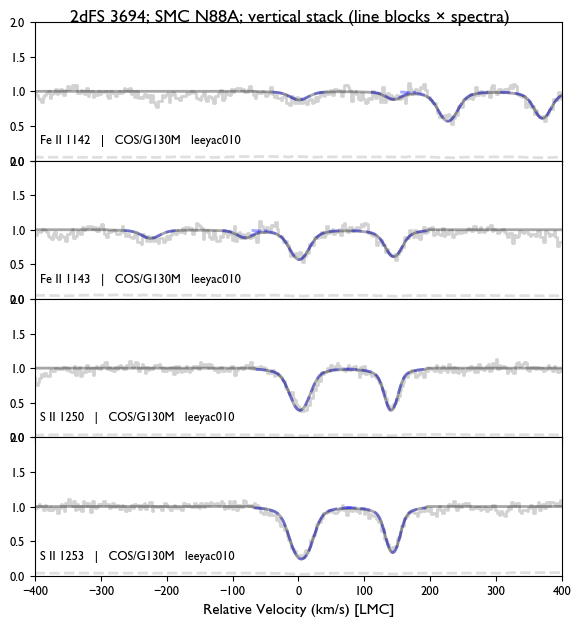

In [11]:
import os
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

def wave_to_vel(w, wrest, c_kms=299792.458):
    return c_kms * (w / wrest - 1.0)

def vel_to_wave(v, wrest, c_kms=299792.458):
    return wrest * (1.0 + v / c_kms)

def read_norm_spectrum(fitinsp_path, contfit_path):
    with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
        w1 = h1["WAVELENGTH"].data.astype(float)
        f1 = h1["FLUX"].data.astype(float)
        c1 = h1["CONTINUUM"].data.astype(float)
        e1 = h1["ERROR"].data.astype(float)

        w2 = h2["WAVELENGTH"].data.astype(float)
        f2 = h2["FLUX"].data.astype(float)
        c2 = h2["CONTINUUM"].data.astype(float)
        e2 = h2["ERROR"].data.astype(float)

    f1n = f1 / np.where(c1 == 0, np.nan, c1)
    e1n = e1 / np.where(c1 == 0, np.nan, c1)
    f2n = f2 / np.where(c2 == 0, np.nan, c2)
    e2n = e2 / np.where(c2 == 0, np.nan, c2)

    mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
    return w1[mask], f1n[mask], e1n[mask], f2n[mask], e2n[mask]

def style_axis(ax, xlim=(-400, 400), ylim=(0, 2), labelsize=10):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=labelsize)

# --- Desired line order (top -> bottom blocks) ---
LINE_COLS = [
    dict(label="Fe II 1142", wrest=1142.3660),
    dict(label="Fe II 1143", wrest=1143.2260),
    dict(label="Fe II 1608", wrest=1608.4511),
    dict(label="Fe II 1611", wrest=1611.2005),
    dict(label="Fe II 2249", wrest=2249.8768),
    dict(label="Fe II 2260", wrest=2260.7805),
    dict(label="S II 1250",  wrest=1250.5840),
    dict(label="S II 1253",  wrest=1253.8110),
]

c_kms = 299792.458
X_LIM = (-400, 400)
Y_LIM = (0, 2)
COVERAGE_PAD_A = 0.5
WREST_MATCH_TOL_A = 1.0

# --- derive allowed lines per grating from your LINESETS ---
ALLOWED_LINES_BY_GRATING = {}
for grat, panel_list in LINESETS.items():
    allowed = []
    for p in panel_list:
        allowed.extend(p["lines"])
    ALLOWED_LINES_BY_GRATING[grat] = np.array(sorted(set(allowed)), dtype=float)

def grating_allows_line(grating, wrest, tol=1e-3):
    if grating not in ALLOWED_LINES_BY_GRATING:
        return False
    return np.any(np.abs(ALLOWED_LINES_BY_GRATING[grating] - wrest) < tol)

# --- collect all spectra (subdirs) across all spectra_directories ---
spectra_items = []
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory

    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if not path.exists():
        continue

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory=directory,
            subdir=subdir,
            subdir_path=subdir_path,
            contfit_path=cont_matches[0],
            fitinsp_path=fitinsp_matches[0],
            partial_paths=list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument=instrument,
            grating=grating,
        ))

# sort spectra within each line block (optional)
spectra_items.sort(key=lambda d: (d["grating"], d["subdir"]))

# --- build the vertical panel list: (line, spectrum) pairs that should exist ---
panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol=1e-3):
            continue
        panels.append((line, item))

if len(panels) == 0:
    raise RuntimeError("No (line, spectrum) panels matched LINESETS.")

# --- ONE figure, ALL vertical, share x-axis ---
fig, axes = plt.subplots(
    nrows=len(panels), ncols=1,
    figsize=(6.8, 1.6 * len(panels)),
    sharex=True
)
axes = np.atleast_1d(axes)

fig.suptitle(f"{target}; {region}; vertical stack (line blocks × spectra)", fontsize=13, y=0.995)

for ax, (line, item) in zip(axes, panels):
    wrest = line["wrest"]

    # read this spectrum (per panel; simple & robust)
    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    # optional: also require wavelength coverage for this line-window
    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle="steps-mid", lw=2.0, color="0.5", alpha=0.35)
    ax.plot(v, f1n, lw=2.0, alpha=0.35, color="0")
    ax.plot(v, e2n, lw=2.0, ls="--", alpha=0.25, color="0.5")

    # partial models for this spectrum routed to this line
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "blue" if (z_partial is not None and z_partial < 0.0005) else "orange"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        ax.plot(vp, mp_plot, lw=2.0, ls="--", alpha=0.35, color=colr)

    style_axis(ax, xlim=X_LIM, ylim=Y_LIM, labelsize=9)

    # left-side label: line + spectrum id
    ax.text(
        0.01, 0.10,
        f"{line['label']}   |   {item['instrument']}/{item['grating']}   {item['subdir']}",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=9
    )

# x label only once at bottom
axes[-1].set_xlabel("Relative Velocity (km/s) [LMC]", fontsize=11)

# hide x tick labels except bottom
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

fig.subplots_adjust(hspace=0.0, top=0.975)

outfile = target_directory / f"{target}_{region}_VERTICAL_all_lines_all_spectra.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


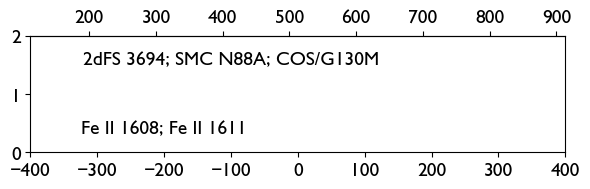

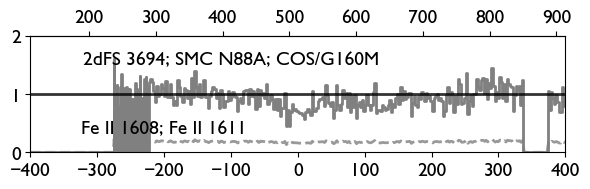

In [12]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        fe_1142 = 1608.451
        fe_1143 = 1611.201
        c_kms = 299792.458
        
        v_1142 = c_kms * (w / fe_1142 - 1.0)
        v_1143 = c_kms * (w / fe_1143 - 1.0)
        
        def v1143_to_v1142(v_in):
            w_in = fe_1143 * (1.0 + v_in / c_kms)
            return c_kms * (w_in / fe_1142 - 1.0)
        
        def v1142_to_v1143(v1142_in):
            w_in = fe_1142 * (1.0 + v1142_in / c_kms)
            return c_kms * (w_in / fe_1143 - 1.0)

        y0, y1 = 0.5, 1.5
        
        fig, ax = plt.subplots(figsize = (6, 2))

        ax.plot(v_1143, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        ax.plot(v_1143, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')
        ax.plot(v_1143, e2n, color =" 0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error")
        
        ax.text(-200, 0.4, "Fe II 1608; Fe II 1611", fontsize = 14, ha = "center", va = "center")
        ax.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)
        
        ax.tick_params(axis = "both", which = "major", labelsize = 14)
        ax.set_xlim(-400, 400)
        ax.set_ylim(0, 2)
        
        secax = ax.secondary_xaxis('top', functions=(v1143_to_v1142, v1142_to_v1143))
        secax.tick_params(axis = "x", which = "major", labelsize = 14)
        
        fig.tight_layout()
        outfile = subdir_path / "Fe II 1608 1611.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

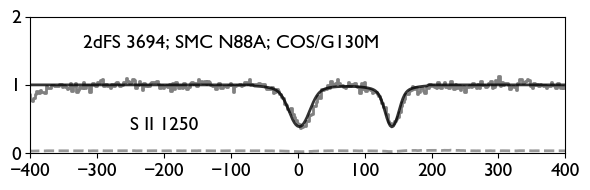

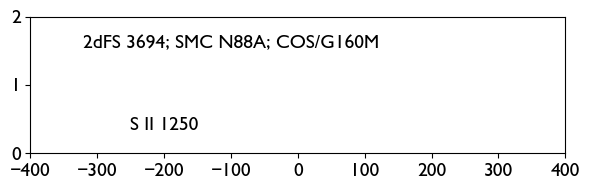

In [13]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w   = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        lam0 = 1250.5840
        c_kms = 299792.458
        
        v_center = 260.0
        dv = 800.0

        v = c_kms * (w / lam0 - 1.0)
        
        plt.figure(figsize = (6, 2))
        plt.plot(v, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        plt.plot(v, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')

        step = max(1, len(v) // 8000)
        plt.plot(v, e2n, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error",)

        plt.text(-200, 0.4, "S II 1250", fontsize = 14, ha = "center", va = "center")

        plt.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        plt.tick_params(axis = "both", which = "major", labelsize = 14)
        plt.xlim(-400, 400)
        plt.ylim(0, 2)
        plt.tight_layout()
        outfile = subdir_path / "S II 1250.png"
        plt.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close()

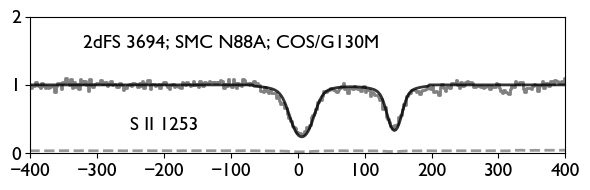

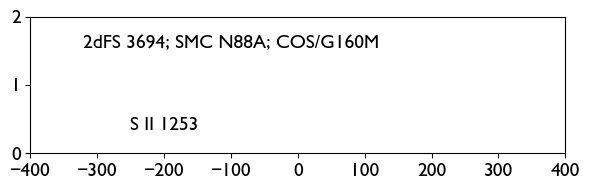

In [14]:
for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))

        if not cont_matches or not fitinsp_matches:
            continue 

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
        w   = w1[mask]
        f1n = f1n[mask]
        e1n = e1n[mask]
        f2n = f2n[mask]
        e2n = e2n[mask]

        lam0 = 1253.805
        c_kms = 299792.458
        
        v_center = 260.0
        dv = 800.0

        v = c_kms * (w / lam0 - 1.0)
        
        plt.figure(figsize = (6, 2))
        plt.plot(v, f2n, drawstyle = "steps-mid", lw = 2.0, label = "continuumfit: FLUX/CONTINUUM", color = '0.5')
        plt.plot(v, f1n, lw = 2.0, alpha = 0.8, label = "FitInspection: FLUX/CONTINUUM", color = '0')

        step = max(1, len(v) // 8000)
        plt.plot(v, e2n, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8, label = "continuumfit 1σ error",)

        plt.text(-200, 0.4, "S II 1253", fontsize = 14, ha = "center", va = "center")

        plt.text(-100, 1.6, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        plt.tick_params(axis = "both", which = "major", labelsize = 14)
        plt.xlim(-400, 400)
        plt.ylim(0, 2)
        plt.tight_layout()
        outfile = subdir_path / "S II 1253.png"
        plt.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close()

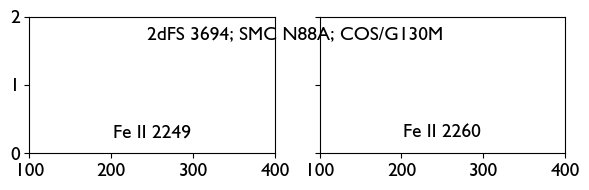

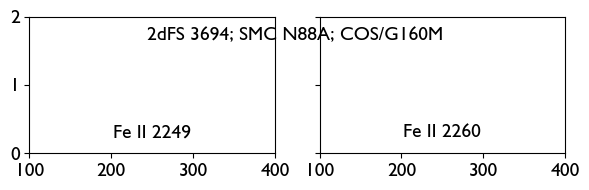

In [15]:
LINES = [
    ("Fe II 2249", 2249.877),
    ("Fe II 2260", 2260.780),
]

for i in range(len(spectra_directories)):
    directory = spectra_directories[i]
    path = target_directory / directory
    instrument = df.loc[i, "Instrument"]
    grating = df.loc[i, "Grating"]

    for subdir in os.listdir(path):
        subdir_path = path / subdir
        if not subdir_path.is_dir():
            continue

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        contfit_path = cont_matches[0]
        fitinsp_path = fitinsp_matches[0]

        with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
            w1 = h1["WAVELENGTH"].data.astype(float)
            f1 = h1["FLUX"].data.astype(float)
            c1 = h1["CONTINUUM"].data.astype(float)
            e1 = h1["ERROR"].data.astype(float)

            w2 = h2["WAVELENGTH"].data.astype(float)
            f2 = h2["FLUX"].data.astype(float)
            c2 = h2["CONTINUUM"].data.astype(float)
            e2 = h2["ERROR"].data.astype(float)

        f1n = f1 / np.where(c1 == 0, np.nan, c1)
        e1n = e1 / np.where(c1 == 0, np.nan, c1)
        f2n = f2 / np.where(c2 == 0, np.nan, c2)
        e2n = e2 / np.where(c2 == 0, np.nan, c2)

        mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n) & np.isfinite(e2n)
        w = w1[mask]
        f1n_m = f1n[mask]
        f2n_m = f2n[mask]
        e2n_m = e2n[mask]

        c_kms = 299792.458

        fig, axes = plt.subplots(1, 2, figsize = (6, 2), sharey = True)

        for ax, (label, lam0) in zip(axes, LINES):
            v = c_kms * (w / lam0 - 1.0)

            ax.plot(v, f2n_m, drawstyle = "steps-mid", lw = 2.0, color = "0.5")
            ax.plot(v, f1n_m, lw = 2.0, alpha = 0.8, color = "0")
            ax.plot(v, e2n_m, color = "0.5", ls = "--", lw = 2.0, alpha = 0.8)

            ax.set_xlim(100, 400)
            ax.set_ylim(0, 2)
            ax.tick_params(axis = "both", which = "major", labelsize = 14)
            ax.text(0.5, 0.15, label, transform = ax.transAxes, fontsize = 14, ha = "center", va = "center")

        fig.text(0.5, 0.8, f"{target}; {region}; {instrument}/{grating}", ha = "center", va = "center", fontsize = 14)

        fig.tight_layout()

        outfile = subdir_path / "FeII 2249 2260.png"
        fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
        plt.show()
        plt.close(fig)

In [16]:
# END